# Figure Generation

Figures are saved to `stentFIT/figures/`. Follow the pipeline:
1. **Stent mesh render** ← here
2. GIF: 2D skeleton tuning
3. 3D skeleton inside stent point cloud
4. 3D skeleton alone
5. Generated artery
6. Fit check output
7. Mixed-dim simulation result

In [14]:
import numpy as np
import pandas as pd
import trimesh
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from pathlib import Path

REPO_ROOT  = Path('../..').resolve()
STENT_DIR  = REPO_ROOT / 'input_examples' / 'stent_designs'
OUTPUT_DIR = REPO_ROOT / 'notebook_outputs'
FIG_DIR    = REPO_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

---
## 1 — Stent mesh render
Set `STENT_NAME` to any STL file stem in `input_examples/stent_designs/`.

In [15]:
STENT_NAME = '2crownCrimpedXienceStent'
# Other options: # Never run 16crownCrimpedXienceStent because it is too big and causes memory issues
#   '2crownCrimpedXienceStent'

In [16]:
def render_stent_mesh(
    stl_path,
    out_path,
    figsize=(6, 6),
    elev=25,
    azim=-55,
    face_color=(0.72, 0.78, 0.86),   # steel blue
    light_dir=(1.0, 0.8, 1.5),
    ambient=0.35,
    dpi=300,
    rotate=False,                    # True -> save a turntable frame sequence
    n_frames=36,                     # frames over a full 360° azimuth sweep
    rot_dir=None,                    # output dir for frames (default: out_path.parent/'rotation_mesh')
):
    """Render an STL stent mesh with Lambertian shading.

    rotate=False -> one PNG at (elev, azim) saved to out_path.
    rotate=True  -> n_frames PNGs sweeping azimuth 360°, saved to rot_dir.
                    Frames are written WITHOUT tight bbox so every frame has the
                    same pixel size (a stable, non-jittering GIF)."""
    mesh = trimesh.load(str(stl_path), force='mesh')

    verts     = np.array(mesh.vertices)
    triangles = verts[np.array(mesh.faces)]

    ld       = np.array(light_dir, dtype=float) / np.linalg.norm(light_dir)
    diffuse  = np.clip(np.array(mesh.face_normals) @ ld, 0, 1)
    intensity = ambient + (1.0 - ambient) * diffuse
    colors   = np.clip(intensity[:, None] * np.array(face_color), 0, 1)

    fig = plt.figure(figsize=figsize, facecolor='white')
    ax  = fig.add_subplot(111, projection='3d', facecolor='white')

    ax.add_collection3d(
        Poly3DCollection(triangles, facecolors=colors, edgecolors='none', alpha=1.0)
    )

    bb_min, bb_max = verts.min(0), verts.max(0)
    center = (bb_min + bb_max) / 2
    half   = (bb_max - bb_min).max() / 2 * 1.05
    ax.set_xlim(center[0] - half, center[0] + half)
    ax.set_ylim(center[1] - half, center[1] + half)
    ax.set_zlim(center[2] - half, center[2] + half)

    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])

    if rotate:
        rot_dir = Path(rot_dir) if rot_dir is not None else out_path.parent / 'rotation_mesh'
        rot_dir.mkdir(parents=True, exist_ok=True)
        for _old in rot_dir.glob('rot_*.png'):
            _old.unlink()
        for k in range(n_frames):
            ax.view_init(elev=elev, azim=azim + 360.0 * k / n_frames)
            fig.savefig(str(rot_dir / f'rot_{k:03d}.png'), dpi=dpi, facecolor='white')
        plt.close(fig)
        print(f'Saved {n_frames} rotation frames → {rot_dir}')
    else:
        ax.view_init(elev=elev, azim=azim)
        fig.tight_layout(pad=0)
        fig.savefig(str(out_path), dpi=dpi, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        print(f'Saved → {out_path}')


# --- find the STL (handles both .stl and .STL extensions) ---
stl_candidates = list(STENT_DIR.glob(f'{STENT_NAME}.*'))
assert stl_candidates, f'No STL found for "{STENT_NAME}" in {STENT_DIR}'
stl_path = stl_candidates[0]

# Create output directory for this stent if it doesn't exist
(FIG_DIR / STENT_NAME).mkdir(exist_ok=True)

ROTATE_MESH = False     # set True to save a 360° turntable sequence instead of one image

render_stent_mesh(
    stl_path = stl_path,
    out_path = FIG_DIR / STENT_NAME / f'{STENT_NAME}_render_mesh.png',
    rotate   = ROTATE_MESH,
    n_frames = 36,
)

Saved → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/figures/2crownCrimpedXienceStent/2crownCrimpedXienceStent_render_mesh.png


---
## 2 — Skeleton tuning frames (for the GIF)

Reproduces the `stent_skeleton.ipynb` pipeline (preprocess → segment → unroll),
then runs a **copy** of `tune_skeleton_params` whose only change is that it saves
the quality-report image at *every* tuner iteration into
`figures/<STENT_NAME>/tuning/`. Each frame's title carries `idx`, `pps`,
`dilate_px`, `penalty`, `score`. Feed those frames to any "images → GIF" site.

`stent_funcs.py` is **not** modified — the loop body is copied here and only the
per-iteration save is added.

In [17]:
import sys, os, time
from collections import Counter
from scipy.spatial import cKDTree

sys.path.insert(0, os.path.abspath('..'))   # so `functions` is importable
from functions.stent_funcs import (
    compute_pre_stent_size_ratio,
    preprocess_stent,
    segment_stent,
    open_stent_to_plane,
    compute_skeleton_2d,
    check_skeleton_quality,
    plot_skeleton_quality,
)

In [18]:
# ── Tuning config (same defaults as stent_skeleton.ipynb) ─────────────────────
SEGMENTATION_WANTED = True
SMALL_LOGIC         = 'or'
PIXELS_PER_STRUT    = 20       # tuner start value
DILATE_PX           = 3        # tuner start value
PAD_FRACTION        = 0.20
TUNE_TIME_LIMIT     = 180.0

REMOVE_SUPPORTS    = (STENT_NAME == '16crownCrimpedXienceStent+extremaSupports')
OVERRIDE_N_SAMPLES = None

# ── Locate STL (handles .stl / .STL) ──────────────────────────────────────────
stl_path = next(iter(STENT_DIR.glob(f'{STENT_NAME}.*')))
original_mesh = trimesh.load(str(stl_path))

# ── Pre-calc: estimate size to set sampling density ───────────────────────────
pre = compute_pre_stent_size_ratio(original_mesh)
target_samples = int(1e6) if (pre['size_ratio'] < 10 or pre['length'] < 15) else int(1e7)
print(f"size_ratio={pre['size_ratio']:.2f}, length={pre['length']:.2f} mm "
      f"-> target_samples={target_samples:.0e}")

samples_per_face   = 1
n_thickness_slices = 100
slice_cutoff       = int(n_thickness_slices * 0.05)

n_faces   = len(original_mesh.faces)
n_samples = n_faces * samples_per_face
if n_samples > 10 * target_samples:
    n_samples //= 10
elif n_samples < target_samples * 0.5:
    n_samples *= 10
if OVERRIDE_N_SAMPLES is not None:
    n_samples = OVERRIDE_N_SAMPLES
print(f"Sampling {n_samples:,} points from {n_faces:,} faces.")

# ── Step 1: preprocess ────────────────────────────────────────────────────────
pre_res = preprocess_stent(
    mesh=original_mesh, n_samples=n_samples, samples_per_face=samples_per_face,
    n_thickness_slices=n_thickness_slices, slice_cutoff=slice_cutoff,
    thickness_calc_plot=False, remove_supports=REMOVE_SUPPORTS,
)
stent_df       = pre_res['stent_df']
stent_features = pre_res['stent_features']

# ── Step 2: segment into pipe-like regions ────────────────────────────────────
n_long_slices = int(2 * np.ceil(stent_features['length'] / stent_features['radius']))
seg = segment_stent(
    stent_df=stent_df, n_long_slices=n_long_slices,
    segmentation_wanted=SEGMENTATION_WANTED,
    strut_thickness=stent_features['strut_thickness'],
    small_logic=SMALL_LOGIC, show_plots=False,
)
stent_df       = seg['stent_df']
region_allowed = seg['region_allowed']
stent_features['n_regions']      = seg['n_regions']
stent_features['conn_radius_3d'] = seg['conn_radius_3d']

# ── Step 3: unroll to the (arc, z) plane ──────────────────────────────────────
opened   = open_stent_to_plane(
    stent_df=stent_df, r_mid=stent_features['r_mid'], pad_fraction=PAD_FRACTION,
)
arc_flat = opened['arc_flat']
z_flat   = opened['z_flat']
print(f"Ready: {len(stent_df):,} surface points, {stent_features['n_regions']} regions.")

size_ratio=2.28, length=2.72 mm -> target_samples=1e+06
Sampling 2,203,267 points from 2,203,267 faces.
[6.1.5] conn_radius_3d=0.0059  (density-based=0.0059, strut-based=0.1547)
[6.1.5] 113 raw regions | small if count<13731 OR diag<0.295 mm | merging 12 (count-only=12, diag-only=8)
[6.1.5] → 101 regions after merge
Ready: 2,203,267 surface points, 101 regions.


In [19]:
# =============================================================================
# COPY of stent_funcs.tune_skeleton_params with ONE addition: at every iteration
# the quality report (plot_skeleton_quality) is saved as a PNG frame, titled with
# idx / pps / dilate_px / penalty / score. The tuning logic is byte-for-byte the
# original — only the `frame_dir` parameter and the save block are new.
# =============================================================================
def tune_skeleton_params_frames(
    arc, z, stent_df, stent_features, region_allowed,
    pps0=10.0, dil0=3, pps_min=5.0, pps_max=120.0, dil_min=1, dil_max=30,
    s_pps_conn=25.0, s_pps_empty=20.0, s_pps_loop=15.0, s_pps_explore=5.0,
    s_dil_loop=20.0, s_dil_conn=8.0,
    w_conn=1.0, w_loop=1.0, w_empty=1.0, w_pps_dil_ratio_reward=4,
    reward_no_improve_max=3, reward_improve_tol=1e-2, target_penalty=0.0,
    max_repeats=4, pad_fraction=0.20, time_limit=100.0, predictive_stop=False,
    max_iters=int(1e3), plot=True, verbose=True,
    frame_dir=None, frame_dpi=130,          # <-- NEW: where/how to save per-iteration frames
):
    r_mid = stent_features['r_mid']
    circ  = 2 * np.pi * r_mid

    surf_tree = cKDTree(np.column_stack([r_mid * stent_df['theta'].to_numpy(),
                                         stent_df['z'].to_numpy()]))
    surf_reg     = stent_df['region'].to_numpy()
    n_regions    = int(stent_df['region'].max())
    region_sizes = stent_df['region'].value_counts()
    med_size     = float(np.median(region_sizes.to_numpy()))

    def _errors(qr):
        n_conn = len(qr['bad_connections'])
        n_loop = int(sum(qr['region_loops'].values()))
        if qr['empty_regions']:
            e_empty = sum(float(region_sizes.get(er, 0)) for er in qr['empty_regions']) / med_size
        else:
            e_empty = 0.0
        return n_conn, n_loop, e_empty

    pps = float(pps0)
    dil = int(np.clip(round(dil0), dil_min, min(dil_max, int(pps))))
    best, history = None, []
    seen = Counter()
    best_bucket = None
    feasible_reached = False
    no_improve = 0
    t0 = time.time()
    durs = []

    if verbose:
        print(f"{'step':>4} {'pps':>7} {'dil_px':>6} | {'conn':>5} {'loop':>5} {'empty':>6} "
              f"| {'penalty':>8} {'score':>8} | {'t(s)':>5}")
        print("-" * 75)

    for it in range(max_iters):
        elapsed = time.time() - t0
        if elapsed > time_limit:
            print(f"[tune] time limit ({time_limit:.0f}s) reached — stopping")
            break
        if predictive_stop and durs:
            growth = durs[-1] / durs[-2] if len(durs) >= 2 and durs[-2] > 0 else 1.0
            proj   = durs[-1] * max(1.0, growth)
            if elapsed + proj > time_limit:
                print(f"[tune] next step projected ~{proj:.0f}s — would exceed the "
                      f"{time_limit:.0f}s budget at t={elapsed:.0f}s — stopping")
                break

        _it_t0 = time.time()
        res = compute_skeleton_2d(
            arc_flat=arc, z_flat=z, arc_min_flat=arc.min(), arc_max_flat=arc.max(),
            circumference=circ, stent_df=stent_df, stent_geometry=stent_features,
            pixels_per_strut=pps, dilate_px=dil, pad_fraction=pad_fraction, plot=False,
        )
        qr = check_skeleton_quality(
            res['df_skeleton_2d'], res['pixel_size'], stent_df, r_mid, region_allowed,
            surf_tree=surf_tree, surf_reg=surf_reg, verbose=False,
        )
        durs.append(time.time() - _it_t0)
        n_conn, n_loop, e_empty = _errors(qr)
        P = w_conn * n_conn + w_loop * n_loop + w_empty * e_empty
        reward = w_pps_dil_ratio_reward * (pps/dil - pps_min/dil_max) / (pps_max/dil_min - pps_min/dil_max)
        score  = reward - P
        elapsed = time.time() - t0
        history.append(dict(step=it, pps=round(pps, 2), dil_px=dil, conn=n_conn,
                            loop=n_loop, empty=round(e_empty, 2),
                            penalty=round(P, 3), score=round(score, 3), t=round(elapsed, 1)))
        if verbose:
            print(f"{it:>4} {pps:>7.2f} {dil:>6d} | {n_conn:>5d} {n_loop:>5d} "
                  f"{e_empty:>6.2f} | {P:>8.3f} {score:>8.3f} | {elapsed:>5.1f}")

        # ── NEW: save the quality report for THIS iteration as a GIF frame ─────
        if frame_dir is not None:
            plot_skeleton_quality(res, stent_df, r_mid, qr)   # builds a fig, plt.show() is a no-op on Agg
            ffig = plt.gcf()
            ffig.suptitle(
                f"idx={it}   pps={pps:.2f}   dilate_px={dil}   "
                f"penalty={P:.3f}   score={score:.3f}",
                fontsize=14, y=1.02,
            )
            ffig.savefig(os.path.join(str(frame_dir), f"frame_{it:03d}.png"),
                         dpi=frame_dpi, bbox_inches='tight', facecolor='white')
            plt.close(ffig)

        ratio        = pps / dil
        score_bucket = round(score / reward_improve_tol)
        cand_key     = (score_bucket, ratio)
        if best is None or cand_key > best['key']:
            best = dict(key=cand_key, score=score, ratio=ratio, penalty=P, pps=pps,
                        dil=dil, conn=n_conn, loop=n_loop, empty=e_empty,
                        result=res, quality_report=qr)

        if P <= target_penalty:
            feasible_reached = True
        if feasible_reached:
            if best_bucket is None or score_bucket > best_bucket:
                best_bucket = score_bucket
                no_improve  = 0
            else:
                no_improve += 1
                if no_improve >= reward_no_improve_max:
                    print(f"[tune] reward not improved for {no_improve} steps since "
                          f"reaching a clean skeleton — stopping (converged)")
                    break

        key = (round(pps, 2), dil)
        seen[key] += 1
        if seen[key] >= max_repeats:
            print(f"[tune] same parameters (pps={pps:.2f}, dil_px={dil}) seen "
                  f"{max_repeats}× — stopping (cycle / pinned)")
            break

        if P <= target_penalty:
            pps_new = pps + s_pps_explore
            dil_new = dil
        else:
            e_conn_n  = min(1.0, n_conn  / max(1, n_regions))
            e_loop_n  = min(1.0, n_loop  / max(1, n_regions))
            e_empty_n = min(1.0, e_empty / max(1, n_regions))
            dil_cap   = min(dil_max, int(pps))
            pps_new = pps + s_pps_conn * e_conn_n + s_pps_empty * e_empty_n
            dil_new = dil + int(round(s_dil_loop * e_loop_n)) \
                          - int(round(s_dil_conn * e_conn_n))
            if n_loop > 0 and dil >= dil_cap:
                pps_new -= s_pps_loop * e_loop_n

        pps = float(np.clip(pps_new, pps_min, pps_max))
        dil = int(np.clip(dil_new, dil_min, min(dil_max, int(pps))))

    hist_df = pd.DataFrame(history)
    print("\n[tune] BEST  pps={:.2f}  dilate_px={}  penalty={:.3f}  score={:.3f}  "
          "(conn={}, loop={}, empty={:.2f})".format(
              best['pps'], best['dil'], best['penalty'], best['score'],
              int(best['conn']), int(best['loop']), best['empty']))

    if plot:
        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.plot(hist_df['step'], hist_df['penalty'], '-', color='steelblue', label='penalty')
        ax.plot(hist_df['step'], hist_df['score'],   '-', color='crimson',   label='score')
        ax.axhline(0, color='grey', lw=0.8, ls=':')
        ax.set_xlabel('step'); ax.set_ylabel('penalty / score'); ax.set_title('tuning trajectory')
        ax2 = ax.twinx()
        ax2.plot(hist_df['step'], hist_df['pps'],    '--', color='darkorange', label='pps')
        ax2.plot(hist_df['step'], hist_df['dil_px'], '--', color='seagreen',   label='dilate_px')
        ax2.set_ylabel('pps / dilate_px')
        ax.legend(loc='upper right'); ax2.legend(loc='center right')
        plt.tight_layout(); plt.show()

    return {
        'best_pps'       : best['pps'],
        'best_dilate_px' : best['dil'],
        'best_penalty'   : best['penalty'],
        'history'        : hist_df,
        'skeleton_2d'    : best['result'],
        'quality_report' : best['quality_report'],
    }

step     pps dil_px |  conn  loop  empty |  penalty    score |  t(s)
---------------------------------------------------------------------------
   0   20.00      3 |    34     0   2.01 |   36.015  -35.798 |   0.1


/Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/src/functions/stent_funcs.py:1124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


   1   28.81      1 |     6     0   0.00 |    6.000   -5.044 |   0.3
   2   30.30      1 |     5     0   0.00 |    5.000   -3.994 |   0.6
   3   31.54      1 |     5     0   0.00 |    5.000   -3.953 |   0.8
   4   32.78      1 |     4     1   0.00 |    5.000   -3.912 |   1.0
   5   33.77      1 |     4     0   0.00 |    4.000   -2.878 |   1.3
   6   34.76      1 |     4     0   0.00 |    4.000   -2.845 |   1.5
   7   35.75      1 |     4     0   0.00 |    4.000   -2.812 |   1.8
   8   36.74      1 |     4     0   0.00 |    4.000   -2.779 |   2.0
   9   37.73      1 |     4     0   0.00 |    4.000   -2.746 |   2.3
  10   38.72      1 |     4     0   0.00 |    4.000   -2.713 |   2.5
  11   39.71      1 |     4     0   0.00 |    4.000   -2.680 |   2.8
  12   40.70      1 |     5     0   0.00 |    5.000   -3.647 |   3.0
  13   41.93      1 |     5     0   0.00 |    5.000   -3.606 |   3.3
  14   43.17      1 |     5     0   0.00 |    5.000   -3.565 |   3.5
  15   44.41      1 |     5     0 

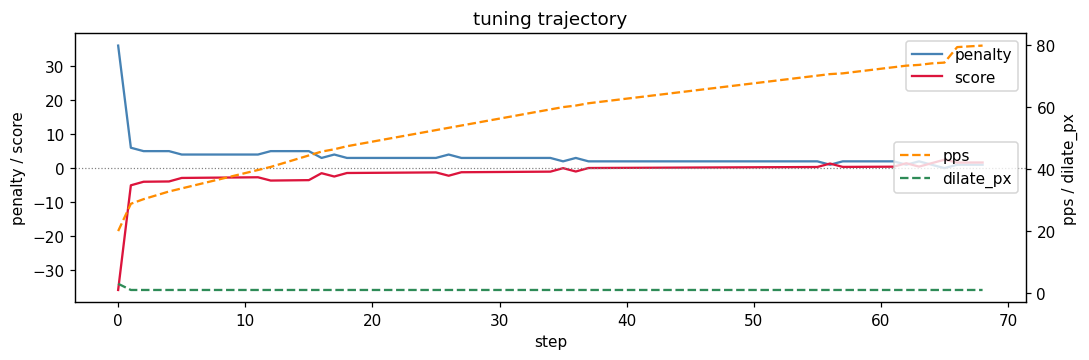

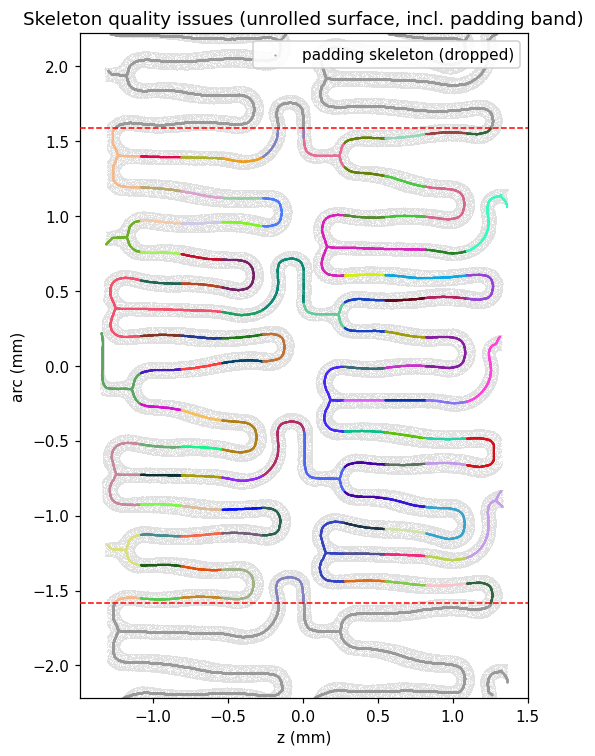

In [20]:
# ── Run the frame-saving tuner ────────────────────────────────────────────────
TUNING_DIR = FIG_DIR / STENT_NAME / 'tuning'
TUNING_DIR.mkdir(parents=True, exist_ok=True)

# clear old frames so the GIF only contains this run
for _old in TUNING_DIR.glob('frame_*.png'):
    _old.unlink()

tune_result = tune_skeleton_params_frames(
    arc            = arc_flat,
    z              = z_flat,
    stent_df       = stent_df,
    stent_features = stent_features,
    region_allowed = region_allowed,
    pps0           = PIXELS_PER_STRUT,
    dil0           = DILATE_PX,
    pad_fraction   = PAD_FRACTION,
    time_limit     = TUNE_TIME_LIMIT,
    plot           = False,            # per-iteration report frames instead of the final trajectory
    frame_dir      = TUNING_DIR,
)

n_frames = len(sorted(TUNING_DIR.glob('frame_*.png')))
print(f"\nSaved {n_frames} frames → {TUNING_DIR}")
print(f"BEST  pps={tune_result['best_pps']:.2f}  "
      f"dilate_px={tune_result['best_dilate_px']}  "
      f"penalty={tune_result['best_penalty']:.3f}")


# ── Show results INLINE (not saved to figures): trajectory + final skeleton ────
# The notebook uses the Agg backend (for batch frame saving), so plt.show() does
# nothing. Render each figure to an in-memory PNG and display() it instead.
import io
from IPython.display import Image, display

def _show_inline(fig, dpi=110):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    display(Image(data=buf.getvalue()))

# 1) Tuning trajectory (penalty / score / pps / dilate_px vs step)
_h = tune_result['history']
_fig, _ax = plt.subplots(figsize=(10, 3.4))
_ax.plot(_h['step'], _h['penalty'], '-', color='steelblue', label='penalty')
_ax.plot(_h['step'], _h['score'],   '-', color='crimson',   label='score')
_ax.axhline(0, color='grey', lw=0.8, ls=':')
_ax.set_xlabel('step'); _ax.set_ylabel('penalty / score'); _ax.set_title('tuning trajectory')
_ax2 = _ax.twinx()
_ax2.plot(_h['step'], _h['pps'],    '--', color='darkorange', label='pps')
_ax2.plot(_h['step'], _h['dil_px'], '--', color='seagreen',   label='dilate_px')
_ax2.set_ylabel('pps / dilate_px')
_ax.legend(loc='upper right'); _ax2.legend(loc='center right')
_fig.tight_layout()
_show_inline(_fig)

# 2) Final (best) skeleton quality report
plot_skeleton_quality(
    tune_result['skeleton_2d'], stent_df, stent_features['r_mid'],
    tune_result['quality_report'],
)
_show_inline(plt.gcf())

---
## 3 — Extracted 3D skeleton inside the stent point cloud

Reads `notebook_outputs/<STENT_NAME>/{stent_points.csv, skeleton_points.csv}`
and draws the 1D skeleton wireframe (edges from `neighbor_ids`) over a subsample
of the 3D surface point cloud. Saves to
`figures/<STENT_NAME>/<STENT_NAME>_skeleton_in_cloud.png`.

In [21]:
import ast
from matplotlib.lines import Line2D


def render_skeleton_in_cloud(
    stent_name,
    out_path,
    max_cloud_pts=60000,      # subsample the cloud for a renderable figure
    elev=18,
    azim=-72,
    dpi=300,
    bg_color='white',         # figure/axes background ('black' for high contrast)
    cloud_color=None,         # None -> auto-contrast for the chosen background
    cloud_alpha=0.30,         # kept transparent regardless of colour
    cloud_size=1.0,
    skel_color=None,          # None -> auto-contrast red for the chosen background
    skel_lw=1.4,
    show_nodes=False,
    rotate=False,             # True -> save a turntable frame sequence
    n_frames=36,              # frames over a full 360° azimuth sweep
    rot_dir=None,             # output dir for frames (default: out_path.parent/'rotation_skeleton')
):
    """Overlay the extracted 1D skeleton (edges from neighbor_ids) on the 3D
    stent surface point cloud. Reads from notebook_outputs/<stent_name>/.

    rotate=False -> one PNG at (elev, azim) saved to out_path.
    rotate=True  -> n_frames PNGs sweeping azimuth 360°, saved to rot_dir
                    (without tight bbox, so frames keep a constant pixel size)."""
    sdir  = OUTPUT_DIR / stent_name
    cloud = pd.read_csv(sdir / 'stent_points.csv')
    skel  = pd.read_csv(sdir / 'skeleton_points.csv')

    # ── Auto-contrast: blue cloud + red skeleton, tuned to the background ──────
    # dark bg -> lighter/brighter so they glow; light bg -> deeper so they read.
    dark_bg = bg_color not in ('white', 'w', '#ffffff', '#FFFFFF')
    if cloud_color is None:
        cloud_color = '#7fb3ff' if dark_bg else '#1f5fa8'   # light blue / deep blue
    if skel_color is None:
        skel_color  = '#ff4d4d' if dark_bg else '#d10f29'   # bright red / crimson
    txt_color = 'white' if dark_bg else 'black'

    if len(cloud) > max_cloud_pts:
        cloud = cloud.sample(max_cloud_pts, random_state=0)
    cpts = cloud[['x', 'y', 'z']].to_numpy()

    # ── Build skeleton edges from neighbor_ids (dedup i<j) ────────────────────
    pid2xyz = {int(r.skeleton_point_id): (r.x, r.y, r.z) for r in skel.itertuples()}
    segs = []
    for r in skel.itertuples():
        i    = int(r.skeleton_point_id)
        nbrs = r.neighbor_ids
        if isinstance(nbrs, str):
            nbrs = ast.literal_eval(nbrs)
        for j in nbrs:
            j = int(j)
            if i < j and j in pid2xyz:
                segs.append([pid2xyz[i], pid2xyz[j]])
    segs = np.array(segs)

    fig = plt.figure(figsize=(7, 7), facecolor=bg_color)
    ax  = fig.add_subplot(111, projection='3d', facecolor=bg_color)

    ax.scatter(cpts[:, 0], cpts[:, 1], cpts[:, 2],
               s=cloud_size, c=cloud_color, alpha=cloud_alpha, linewidths=0)
    if len(segs):
        ax.add_collection3d(Line3DCollection(segs, colors=skel_color, linewidths=skel_lw))
    if show_nodes:
        ax.scatter(skel['x'], skel['y'], skel['z'], s=3, c=skel_color, linewidths=0)

    # True proportions (the stent is elongated along z)
    allpts = np.vstack([cpts, skel[['x', 'y', 'z']].to_numpy()])
    bb_min, bb_max = allpts.min(0), allpts.max(0)
    ax.set_xlim(bb_min[0], bb_max[0])
    ax.set_ylim(bb_min[1], bb_max[1])
    ax.set_zlim(bb_min[2], bb_max[2])
    ax.set_box_aspect(bb_max - bb_min)
    ax.set_axis_off()

    leg = ax.legend(handles=[
        Line2D([0], [0], marker='o', color=bg_color, markerfacecolor=cloud_color,
               markersize=7, label='3D stent point cloud'),
        Line2D([0], [0], color=skel_color, lw=2.5, label='extracted skeleton'),
    ], loc='upper right', framealpha=0.9)
    for _t in leg.get_texts():
        _t.set_color(txt_color)
    leg.get_frame().set_facecolor(bg_color)
    leg.get_frame().set_edgecolor(txt_color)

    if rotate:
        rot_dir = Path(rot_dir) if rot_dir is not None else out_path.parent / 'rotation_skeleton'
        rot_dir.mkdir(parents=True, exist_ok=True)
        for _old in rot_dir.glob('rot_*.png'):
            _old.unlink()
        for k in range(n_frames):
            ax.view_init(elev=elev, azim=azim + 360.0 * k / n_frames)
            fig.savefig(str(rot_dir / f'rot_{k:03d}.png'), dpi=dpi, facecolor=bg_color)
        plt.close(fig)
        print(f'Saved {n_frames} rotation frames → {rot_dir}  '
              f'({len(segs)} edges, {len(cpts):,} cloud pts)')
    else:
        ax.view_init(elev=elev, azim=azim)
        fig.tight_layout(pad=0)
        fig.savefig(str(out_path), dpi=dpi, bbox_inches='tight', facecolor=bg_color)
        plt.close(fig)
        print(f'Saved → {out_path}  ({len(segs)} edges, {len(cpts):,} cloud pts shown)')


(FIG_DIR / STENT_NAME).mkdir(parents=True, exist_ok=True)

ROTATE_SKELETON = False   # set True to save a 360° turntable sequence instead of one image

render_skeleton_in_cloud(
    STENT_NAME,
    out_path    = FIG_DIR / STENT_NAME / f'{STENT_NAME}_skeleton_in_cloud.png',
    bg_color    = 'white',        # 'black' for the dark high-contrast version
    cloud_color = None,           # None = auto-contrast (blue) for the background
    skel_color  = None,           # None = auto-contrast (red) for the background
    cloud_alpha = 0.50,
    rotate      = ROTATE_SKELETON,
    n_frames    = 90,
)

Saved → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/figures/2crownCrimpedXienceStent/2crownCrimpedXienceStent_skeleton_in_cloud.png  (19585 edges, 60,000 cloud pts shown)


---
## 4 — Generated artery

Builds a parametric artery sized to the current stent with
`generate_artery_for_stent` (from `generate_artery.py`) and renders the shaded
tube. `ARTERY_TYPE` ∈ {`straight`, `curved`, `s_bend`}; noise + bend angle match
the knobs in `sim_trials.ipynb`. Saves to
`figures/<STENT_NAME>/<STENT_NAME>_artery_<type>.png`.

Stent features are read **read-only** from `notebook_outputs/<STENT_NAME>/stent_features.json`
— no source files or outputs are modified.

In [22]:
import json, sys, os
sys.path.insert(0, os.path.abspath('..'))   # so `functions` is importable
from functions.generate_artery import generate_artery_for_stent

if STENT_NAME == '2crownCrimpedXienceStent':
    STENT_NAME = '16crownCrimpedXienceStent+extremaSupports'

# ── Artery config (same knobs as sim_trials.ipynb) ────────────────────────────
ARTERY_TYPE     = 's_bend'    # 'straight' | 'curved' | 's_bend'
NOISE_AMPLITUDE = 0.12       # fractional radius perturbation (0 = smooth, 0.05 = ±5%)
NOISE_SEED      = 42          # int for reproducibility, or None for random
BEND_ANGLE_DEG  = 90          # [deg]  only used for 'curved' / 's_bend'

# ── Load stent features READ-ONLY and wrap to {"value": ...} (no file rewrite) ─
# generate_artery_for_stent only needs features['r_outer'] and features['length'].
with open(OUTPUT_DIR / STENT_NAME / 'stent_features.json') as _f:
    _raw = json.load(_f)

def _unwrap(v):
    while isinstance(v, dict) and 'value' in v:
        v = v['value']
    return v

features = {k: {'value': _unwrap(v)} for k, v in _raw.items()}

# ── Generate the artery sized to this stent ───────────────────────────────────
artery_mesh, artery_cl, artery_radius = generate_artery_for_stent(
    features, ARTERY_TYPE, NOISE_AMPLITUDE, NOISE_SEED, BEND_ANGLE_DEG,
)

Artery type      : s_bend
Artery radius    : 1.603 mm
Noise amplitude  : 0.12 (12% of radius)  seed=42
Bend angle       : 90.0 deg
Bend radius      : 10.19 mm  (2× arc = 32.00 mm)
Arc length       : 35.55 mm  (stent 17.78 mm = 50% of artery)
Centreline       : 151 points  bounds [0. 0. 0.] → [21.56  0.   22.74]
Mesh             : 9,666 vertices  19,328 faces  watertight=True


In [26]:
def render_artery(
    artery_mesh,
    artery_cl,
    out_path,
    figsize=(9, 6),
    elev=20,
    azim=-80,
    dpi=300,
    bg_color='white',                 # 'black' for high contrast
    face_color=(0.80, 0.36, 0.34),    # fleshy red
    light_dir=(1.0, 0.8, 1.5),
    ambient=0.45,
    show_centreline=False,            # gold polyline along the lumen axis
    cl_color='gold',
    rotate=False,                     # True -> turntable frame sequence
    n_frames=36,
    rot_dir=None,                     # default: out_path.parent/'rotation_artery'
):
    """Render a generated artery tube (Lambertian-shaded surface) with optional
    centreline. Mirrors the look of the other 3D renders in this notebook.

    rotate=False -> one PNG at (elev, azim) to out_path.
    rotate=True  -> n_frames PNGs sweeping azimuth 360° to rot_dir (constant size)."""
    verts     = np.array(artery_mesh.vertices)
    triangles = verts[np.array(artery_mesh.faces)]

    ld        = np.array(light_dir, dtype=float) / np.linalg.norm(light_dir)
    diffuse   = np.clip(np.array(artery_mesh.face_normals) @ ld, 0, 1)
    intensity = ambient + (1.0 - ambient) * diffuse
    colors    = np.clip(intensity[:, None] * np.array(face_color), 0, 1)

    fig = plt.figure(figsize=figsize, facecolor=bg_color)
    ax  = fig.add_subplot(111, projection='3d', facecolor=bg_color)

    ax.add_collection3d(
        Poly3DCollection(triangles, facecolors=colors, edgecolors='none', alpha=1.0)
    )
    if show_centreline:
        ax.plot(artery_cl[:, 0], artery_cl[:, 1], artery_cl[:, 2],
                color=cl_color, lw=2.2, zorder=10)

    # True proportions
    bb_min, bb_max = verts.min(0), verts.max(0)
    ax.set_xlim(bb_min[0], bb_max[0])
    ax.set_ylim(bb_min[1], bb_max[1])
    ax.set_zlim(bb_min[2], bb_max[2])
    ax.set_box_aspect(bb_max - bb_min)
    ax.set_axis_off()

    if rotate:
        rot_dir = Path(rot_dir) if rot_dir is not None else out_path.parent / 'rotation_artery'
        rot_dir.mkdir(parents=True, exist_ok=True)
        for _old in rot_dir.glob('rot_*.png'):
            _old.unlink()
        for k in range(n_frames):
            ax.view_init(elev=elev, azim=azim + 360.0 * k / n_frames)
            fig.savefig(str(rot_dir / f'rot_{k:03d}.png'), dpi=dpi, facecolor=bg_color)
        plt.close(fig)
        print(f'Saved {n_frames} rotation frames → {rot_dir}')
    else:
        ax.view_init(elev=elev, azim=azim)
        fig.tight_layout(pad=0)
        fig.savefig(str(out_path), dpi=dpi, bbox_inches='tight', facecolor=bg_color)
        plt.close(fig)
        print(f'Saved → {out_path}')



(FIG_DIR / STENT_NAME).mkdir(parents=True, exist_ok=True)

ROTATE_ARTERY = False   # set True to save a 360° turntable sequence instead of one image

render_artery(
    artery_mesh,
    artery_cl,
    out_path        = FIG_DIR / STENT_NAME / f'artery_{ARTERY_TYPE}.png',
    bg_color        = 'white',
    show_centreline = False,    # True to overlay the gold centreline
    rotate          = ROTATE_ARTERY,
    n_frames        = 36,
)

Saved → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/figures/16crownCrimpedXienceStent+extremaSupports/artery_s_bend.png


---
## 5 — Stent placed inside the artery + fit check

Maps the straight stent skeleton onto the artery centreline
(`map_stent_to_artery`) and renders it **inside** a translucent artery shell.
Then runs the five geometric compatibility checks (`check_stent_artery_fit`) and
renders a colour-coded PASS/FAIL **table**.

Uses the `features`, `artery_mesh`, `artery_cl`, `artery_radius` from Section 4
and the skeleton read **read-only** from `notebook_outputs/<STENT_NAME>/skeleton_points.csv`.
Saves `*_skeleton_in_artery_<type>.png` and `*_fit_check.png` to `figures/<STENT_NAME>/`.

In [27]:
import ast
from functions.process_funcs import map_stent_to_artery

# ── Load the stent skeleton READ-ONLY from notebook_outputs ───────────────────
skel = pd.read_csv(OUTPUT_DIR / STENT_NAME / 'skeleton_points.csv')
skel['neighbor_ids'] = skel['neighbor_ids'].apply(ast.literal_eval)

# ── Curve + place the straight skeleton onto the artery centreline ────────────
skel_mapped, cl_m = map_stent_to_artery(skel, features, artery_cl)


def render_skeleton_in_artery(
    artery_mesh, artery_cl, skel, skel_mapped, out_path,
    figsize=(9, 6), elev=20, azim=-80, dpi=300,
    bg_color='white',
    artery_color=(0.80, 0.36, 0.34), artery_alpha=0.12,   # translucent shell
    skel_color='#10357f', skel_lw=1.6,                     # mapped skeleton wireframe
    show_centreline=False, cl_color='limegreen', cl_lw=2.0, cl_ls='--',
    rotate=False, n_frames=36, rot_dir=None,
):
    """Translucent artery shell with the mapped stent skeleton wireframe inside,
    and optionally the artery centreline as a (dashed) polyline.

    rotate=False -> one PNG at (elev, azim) to out_path.
    rotate=True  -> n_frames PNGs sweeping azimuth 360° to rot_dir (constant size)."""
    # mapped skeleton edges — neighbor_ids index positionally into skel_mapped
    n_nodes = len(skel_mapped)
    segs, seen = [], set()
    for i, nbrs in enumerate(skel['neighbor_ids']):
        pid = int(skel.iloc[i]['skeleton_point_id'])
        for nid in nbrs:
            nid = int(nid)
            if nid >= n_nodes:
                continue
            key = (min(pid, nid), max(pid, nid))
            if key in seen:
                continue
            seen.add(key)
            segs.append([skel_mapped[i], skel_mapped[nid]])
    segs = np.array(segs)

    verts = np.array(artery_mesh.vertices)
    tris  = verts[np.array(artery_mesh.faces)]

    fig = plt.figure(figsize=figsize, facecolor=bg_color)
    ax  = fig.add_subplot(111, projection='3d', facecolor=bg_color)

    ax.add_collection3d(Poly3DCollection(
        tris, facecolors=(*artery_color, artery_alpha), edgecolors='none'))
    if len(segs):
        ax.add_collection3d(Line3DCollection(
            segs, colors=skel_color, linewidths=skel_lw, zorder=10))
    if show_centreline:
        ax.plot(artery_cl[:, 0], artery_cl[:, 1], artery_cl[:, 2],
                color=cl_color, lw=cl_lw, ls=cl_ls, zorder=11, label='artery centreline')

    allpts = np.vstack([verts, skel_mapped])
    bb_min, bb_max = allpts.min(0), allpts.max(0)
    ax.set_xlim(bb_min[0], bb_max[0])
    ax.set_ylim(bb_min[1], bb_max[1])
    ax.set_zlim(bb_min[2], bb_max[2])
    ax.set_box_aspect(bb_max - bb_min)
    ax.set_axis_off()

    if rotate:
        rot_dir = Path(rot_dir) if rot_dir is not None else out_path.parent / 'rotation_skeleton_in_artery'
        rot_dir.mkdir(parents=True, exist_ok=True)
        for _old in rot_dir.glob('rot_*.png'):
            _old.unlink()
        for k in range(n_frames):
            ax.view_init(elev=elev, azim=azim + 360.0 * k / n_frames)
            fig.savefig(str(rot_dir / f'rot_{k:03d}.png'), dpi=dpi, facecolor=bg_color)
        plt.close(fig)
        print(f'Saved {n_frames} rotation frames → {rot_dir}  ({len(segs)} skeleton edges)')
    else:
        ax.view_init(elev=elev, azim=azim)
        fig.tight_layout(pad=0)
        fig.savefig(str(out_path), dpi=dpi, bbox_inches='tight', facecolor=bg_color)
        plt.close(fig)
        print(f'Saved → {out_path}  ({len(segs)} skeleton edges)')


(FIG_DIR / STENT_NAME).mkdir(parents=True, exist_ok=True)

ROTATE_IN_ARTERY = False   # set True to save a 360° turntable sequence instead of one image

render_skeleton_in_artery(
    artery_mesh, artery_cl, skel, skel_mapped,
    out_path        = FIG_DIR / STENT_NAME / f'skeleton_in_artery_{ARTERY_TYPE}.png',
    bg_color        = 'white',
    show_centreline = True,     # dashed centreline overlaid through the lumen
    cl_color        = 'limegreen',
    cl_ls           = '--',
    rotate          = ROTATE_IN_ARTERY,
    n_frames        = 36,
)

Mapped 47,132 skeleton nodes
Saved → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/figures/16crownCrimpedXienceStent+extremaSupports/skeleton_in_artery_s_bend.png  (47641 skeleton edges)


  [3/5] Containment + [4/5] Clearance … 100.0% inside, min clearance 0.658 mm, 0 penetrating
Saved → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/figures/16crownCrimpedXienceStent+extremaSupports/fit_check.png


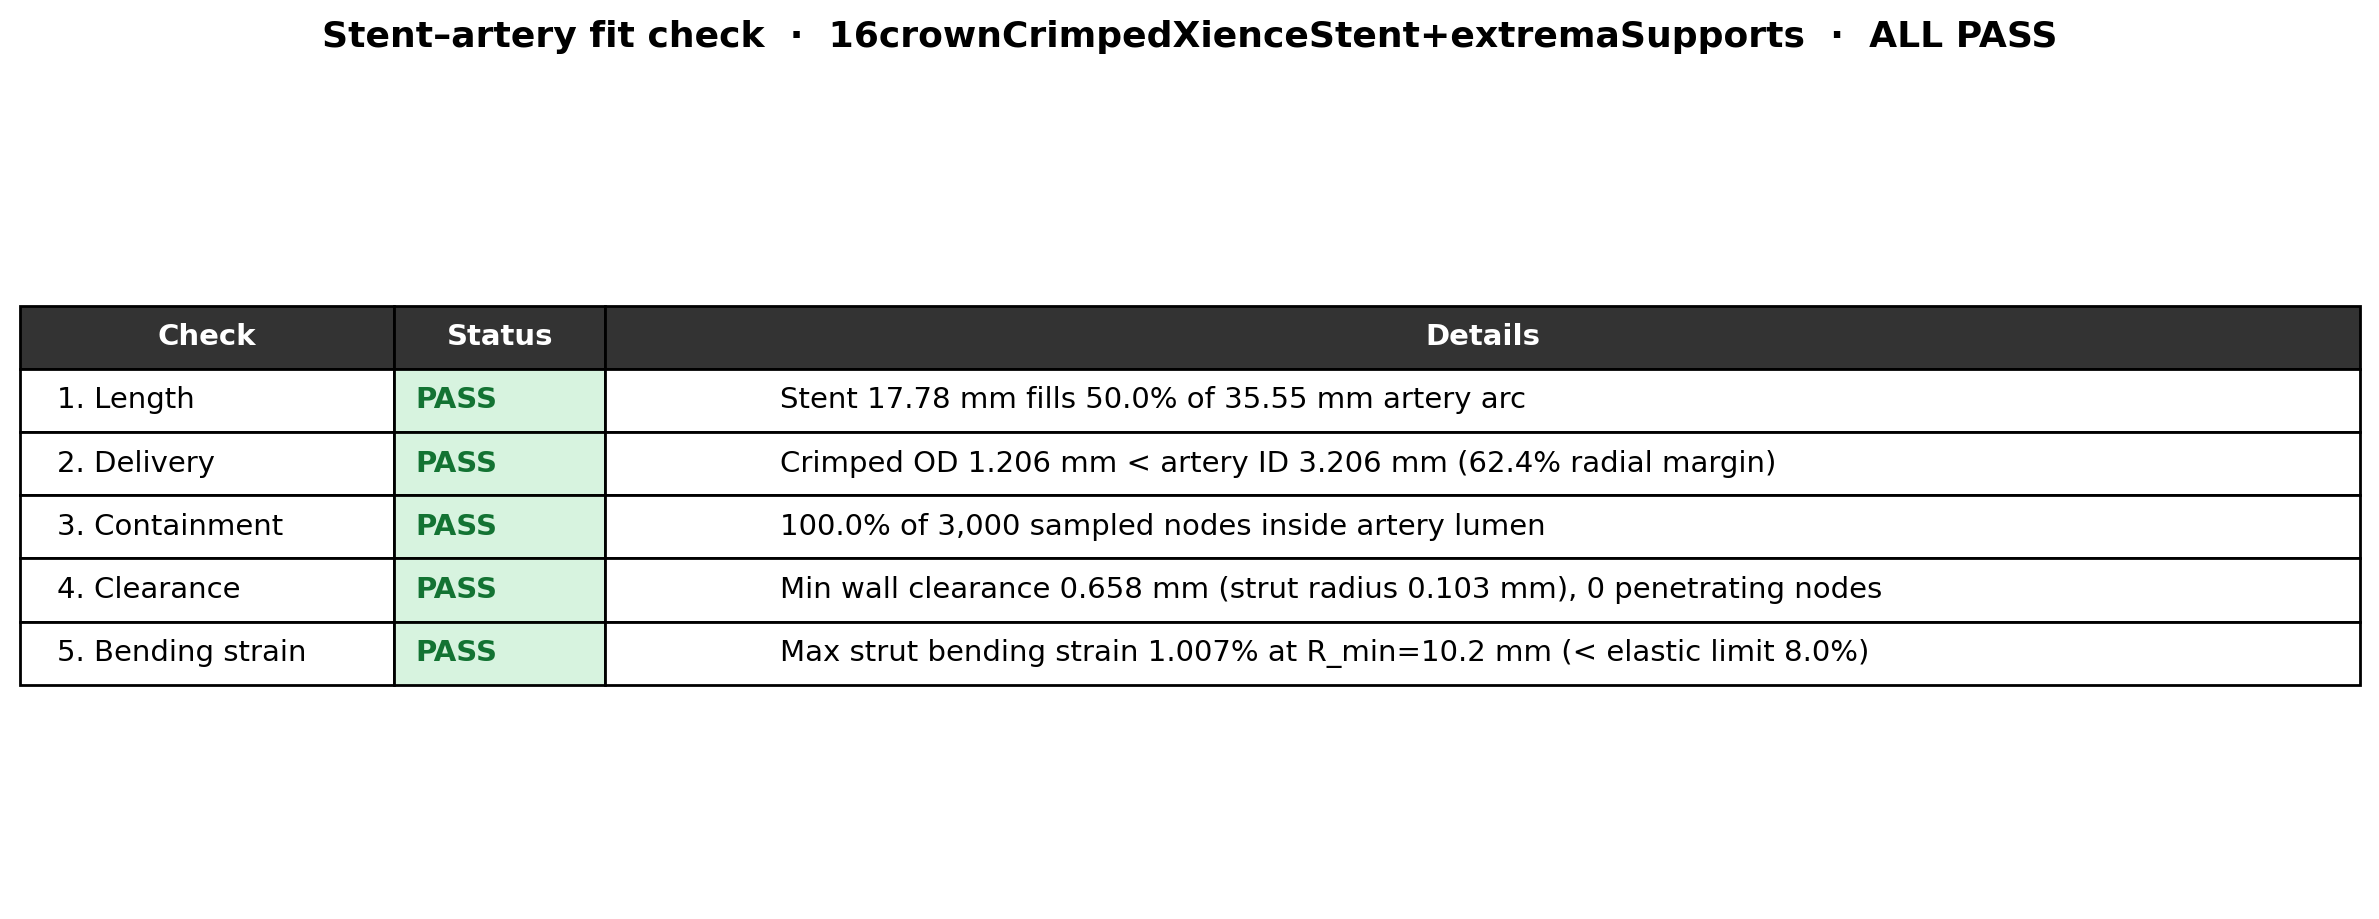

,Check,Status,Details
0,1. Length,PASS,Stent 17.78 mm fills 50.0% of 35.55 mm artery arc
1,2. Delivery,PASS,Crimped OD 1.206 mm < artery ID 3.206 mm (62.4...
2,3. Containment,PASS,"100.0% of 3,000 sampled nodes inside artery lumen"
3,4. Clearance,PASS,Min wall clearance 0.658 mm (strut radius 0.10...
4,5. Bending strain,PASS,Max strut bending strain 1.007% at R_min=10.2 ...


In [29]:
from functions.process_funcs import check_stent_artery_fit
from IPython.display import Image, display

# ── Run the five geometric compatibility checks ───────────────────────────────
checks = check_stent_artery_fit(
    skel_mapped, skel, features, artery_mesh, artery_cl, artery_radius,
)


def make_fit_check_table(checks, out_path, dpi=200):
    """Render the fit-check report as a colour-coded PASS/FAIL table (PNG)."""
    pretty = {'length': '1. Length', 'delivery': '2. Delivery',
              'containment': '3. Containment', 'clearance': '4. Clearance',
              'bending_strain': '5. Bending strain'}
    order  = ['length', 'delivery', 'containment', 'clearance', 'bending_strain']
    rows = [[pretty[k], 'PASS' if checks[k]['passed'] else 'FAIL', checks[k].get('note', '')]
            for k in order if k in checks]
    overall_ok = all(checks[k]['passed'] for k in order if k in checks)

    fig, ax = plt.subplots(figsize=(12, 0.7 * len(rows) + 1.2), facecolor='white')
    ax.axis('off')
    tbl = ax.table(cellText=rows, colLabels=['Check', 'Status', 'Details'],
                   colWidths=[0.16, 0.09, 0.75], cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.5)
    tbl.scale(1, 1.7)

    # header styling
    for j in range(3):
        h = tbl[0, j]
        h.set_facecolor('#333333')
        h.get_text().set_color('white')
        h.get_text().set_weight('bold')
    # status-cell colouring
    for i, row in enumerate(rows):
        s  = tbl[i + 1, 1]
        ok = row[1] == 'PASS'
        s.set_facecolor('#d7f3df' if ok else '#fad7d7')
        s.get_text().set_color('#137333' if ok else '#a50e0e')
        s.get_text().set_weight('bold')

    ax.set_title(
        f'Stent–artery fit check  ·  {STENT_NAME}  ·  '
        f'{"ALL PASS" if overall_ok else "SOME FAILED"}',
        fontsize=13, weight='bold', pad=16,
    )
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return pd.DataFrame(rows, columns=['Check', 'Status', 'Details'])


_tbl_path = FIG_DIR / STENT_NAME / f'fit_check.png'
fit_df = make_fit_check_table(checks, _tbl_path)
print(f'Saved → {_tbl_path}')

# show the table image + the raw DataFrame inline
display(Image(filename=str(_tbl_path)))
display(fit_df)